
# Mouse Alignment Analysis — STAR All 26 (`GRCm39` + Ensembl)

This notebook extends the Trapnell-style alignment walkthrough into a more organized, graduate-level mouse report. It focuses on the canonical `fastp`-cleaned alignment run for all 26 samples and asks three practical questions:

1. Are the STAR alignment metrics strong enough to proceed with the full dataset?
2. Do the remaining GC-WARN samples behave differently from the GC-PASS samples at the alignment stage?
3. Is there visible structure by sequencing platform (`NovaSeq 6000` vs `NovaSeq X`) or biological subgroup that should be carried forward into downstream interpretation?

The notebook parses the local copy of the canonical STAR outputs, caches sample metadata from GEO, builds count-matrix handoff artifacts from `ReadsPerGene.out.tab`, and saves cleaned tables/figures for the individual report and later DE work.


In [1]:

from pathlib import Path
import re
import time
import urllib.request
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.dpi'] = 120



## Data locations and provenance

The canonical local alignment copy lives under the mouse project tree and mirrors the private server-side STAR run. This notebook writes all alignment-analysis artifacts into a dedicated local output folder so the notebook remains reproducible and the deliverables are easy to reuse.


In [2]:

MOUSE_ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse')
ALIGN_ROOT = MOUSE_ROOT / 'alignment_local_server_private_copy' / 'star_grcm39_ensembl_all26_fastp'
SAMPLES_DIR = ALIGN_ROOT / 'samples'
RUNINFO_CSV = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/BIOL550-Lab/project_pic/project_datasets/PRJNA1017789_runinfo.csv')
GC_HEATMAP = MOUSE_ROOT / 'qc_analysis_remediation' / 'multiqc_fastp_trim_only_shared' / 'mouse_fastp_trim_only_multiqc_data' / 'fastqc-status-check-heatmap.txt'
OUT_DIR = MOUSE_ROOT / 'alignment_analysis_star_all26'
FIG_DIR = OUT_DIR / 'figures'
TABLE_DIR = OUT_DIR / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

for path in [ALIGN_ROOT, SAMPLES_DIR, RUNINFO_CSV, GC_HEATMAP]:
    print(f'{path}:', 'OK' if path.exists() else 'MISSING')


/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/alignment_local_server_private_copy/star_grcm39_ensembl_all26_fastp: OK
/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/alignment_local_server_private_copy/star_grcm39_ensembl_all26_fastp/samples: OK
/Users/pitergarcia/DataScience/Semester5/BIOL550/BIOL550-Lab/project_pic/project_datasets/PRJNA1017789_runinfo.csv: OK
/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/qc_analysis_remediation/multiqc_fastp_trim_only_shared/mouse_fastp_trim_only_multiqc_data/fastqc-status-check-heatmap.txt: OK


In [3]:

sample_dirs = sorted([p for p in SAMPLES_DIR.iterdir() if p.is_dir()])
log_files = sorted(SAMPLES_DIR.glob('*/SRR*.Log.final.out'))
reads_files = sorted(SAMPLES_DIR.glob('*/SRR*.ReadsPerGene.out.tab'))
bam_files = sorted(SAMPLES_DIR.glob('*/*.bam'))
bai_files = sorted(SAMPLES_DIR.glob('*/*.bam.bai'))

copy_status = pd.DataFrame([
    {'artifact': 'sample directories', 'expected': 26, 'found': len(sample_dirs)},
    {'artifact': 'Log.final.out files', 'expected': 26, 'found': len(log_files)},
    {'artifact': 'ReadsPerGene.out.tab files', 'expected': 26, 'found': len(reads_files)},
    {'artifact': 'BAM files', 'expected': 26, 'found': len(bam_files)},
    {'artifact': 'BAM index files', 'expected': 26, 'found': len(bai_files)},
])
copy_status['status'] = np.where(copy_status['found'] >= copy_status['expected'], 'complete', 'incomplete')
display(copy_status)

if len(bam_files) < 26:
    display(Markdown(
        f"**Note:** BAM sync is still incomplete locally (`{len(bam_files)}/26` BAMs present). "
        "The STAR log/count analysis below is still valid because it uses `Log.final.out` and `ReadsPerGene.out.tab`, "
        "but any BAM-level follow-up should wait until the file transfer finishes."
    ))


,artifact,expected,found,status
0,sample directories,26,26,complete
1,Log.final.out files,26,26,complete
2,ReadsPerGene.out.tab files,26,26,complete
3,BAM files,26,2,incomplete
4,BAM index files,26,0,incomplete


**Note:** BAM sync is still incomplete locally (`2/26` BAMs present). The STAR log/count analysis below is still valid because it uses `Log.final.out` and `ReadsPerGene.out.tab`, but any BAM-level follow-up should wait until the file transfer finishes.


## Reference and alignment provenance

This run uses the canonical `fastp`-cleaned inputs and the locally selected mouse reference pair (`GRCm39` primary assembly + matching Ensembl annotation). The table below comes from the alignment run metadata recorded when the all-26 STAR run was launched.


In [4]:
run_metadata = pd.read_csv(ALIGN_ROOT / 'run_metadata.tsv', sep='\t')
display(run_metadata)

,key,value
0,decision_scope,all26_first
1,cleaned_input_root,/home/pzg8794/mouse_qc_remediation/output/fast...
2,reference_index,/home/pzg8794/mouse_qc_remediation/reference/g...
3,parallel_split_files,/home/pzg8794/mouse_qc_remediation/runs/PRJNA1...



## Load run-level metadata

The SRA run table gives us the SRR/GSM mapping and platform split. GEO sample pages add the descriptive sample title, source, sex, genotype, and treatment so we can connect alignment behavior back to the biological design.


In [5]:

runinfo = pd.read_csv(RUNINFO_CSV)
runinfo = runinfo[['Run', 'SampleName', 'Model', 'spots', 'bases', 'avgLength', 'size_MB']].rename(
    columns={
        'Run': 'srr',
        'SampleName': 'gsm',
        'Model': 'platform',
        'spots': 'sra_spots',
        'bases': 'sra_bases',
        'avgLength': 'sra_avg_length',
        'size_MB': 'sra_size_mb',
    }
)
runinfo['platform_short'] = runinfo['platform'].str.replace('Illumina ', '', regex=False)
runinfo['srr_numeric'] = runinfo['srr'].str.extract(r'(\d+)').astype(int)
runinfo = runinfo.sort_values('srr_numeric').reset_index(drop=True)
display(runinfo.head())


,srr,gsm,platform,sra_spots,sra_bases,sra_avg_length,sra_size_mb,platform_short,srr_numeric
0,SRR30333743,GSM8476498,Illumina NovaSeq X,50095819,15128937338,302,4633,NovaSeq X,30333743
1,SRR30333744,GSM8476497,Illumina NovaSeq X,45278477,13674100054,302,4148,NovaSeq X,30333744
2,SRR30333745,GSM8476496,Illumina NovaSeq X,47813388,14439643176,302,4401,NovaSeq X,30333745
3,SRR30333746,GSM8476495,Illumina NovaSeq X,42216035,12749242570,302,3859,NovaSeq X,30333746
4,SRR30333747,GSM8476494,Illumina NovaSeq X,41136868,12423334136,302,3795,NovaSeq X,30333747



## Cache GEO sample metadata

To avoid retyping sample labels manually, the notebook caches a compact metadata table from the GEO sample pages. If the cached file already exists, it is reused. Otherwise, the notebook downloads the minimal text view for each GSM accession and parses the key fields we need.


In [6]:

GEO_CACHE = TABLE_DIR / 'geo_sample_metadata.tsv'

def fetch_geo_text(gsm: str) -> str:
    url = f'https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc={gsm}&targ=self&view=full&form=text'
    with urllib.request.urlopen(url, timeout=30) as response:
        return response.read().decode('utf-8', errors='replace')


def parse_geo_text(gsm: str, text: str) -> Dict[str, str]:
    row = {'gsm': gsm}
    characteristics: Dict[str, str] = {}
    descriptions: List[str] = []
    for line in text.splitlines():
        if line.startswith('!Sample_title = '):
            row['sample_title'] = line.split('=', 1)[1].strip()
        elif line.startswith('!Sample_source_name_ch1 = '):
            row['source_name'] = line.split('=', 1)[1].strip()
        elif line.startswith('!Sample_instrument_model = '):
            row['geo_instrument_model'] = line.split('=', 1)[1].strip()
        elif line.startswith('!Sample_description = '):
            descriptions.append(line.split('=', 1)[1].strip())
        elif line.startswith('!Sample_characteristics_ch1 = '):
            payload = line.split('=', 1)[1].strip()
            if ':' in payload:
                key, value = payload.split(':', 1)
                characteristics[key.strip().lower().replace(' ', '_')] = value.strip()
    row.update(characteristics)
    row['sample_description'] = '; '.join(descriptions)
    title = row.get('sample_title', '')
    match = re.search(r', replicate (\d+)$', title)
    row['replicate'] = int(match.group(1)) if match else np.nan
    row['group_label'] = re.sub(r', replicate \d+$', '', title).strip()
    return row

if GEO_CACHE.exists():
    geo_meta = pd.read_csv(GEO_CACHE, sep='	')
else:
    records = []
    for gsm in runinfo['gsm']:
        text = fetch_geo_text(gsm)
        records.append(parse_geo_text(gsm, text))
        time.sleep(0.15)
    geo_meta = pd.DataFrame(records)
    geo_meta.to_csv(GEO_CACHE, sep='	', index=False)

display(geo_meta[['gsm', 'sample_title', 'source_name', 'sex', 'genotype', 'treatment']].head())


,gsm,sample_title,source_name,sex,genotype,treatment
0,GSM8476498,"Control DRG, ipsilateral, replicate 2",Dorsal root ganglia,male,Ahr fl/fl,"WT, 1 day post-sham surgery"
1,GSM8476497,"Control DRG, ipsilateral, replicate 1",Dorsal root ganglia,male,Ahr f/+,"WT, 1 day post-sham surgery"
2,GSM8476496,"Control DRG, contralateral, replicate 2",Dorsal root ganglia,male,Ahr fl/fl,"WT, 1 day post-sham surgery"
3,GSM8476495,"Control DRG, contralateral, replicate 1",Dorsal root ganglia,male,Ahr f/+,"WT, 1 day post-sham surgery"
4,GSM8476494,"Control DRG neurons, replicate 3",Dorsal root ganglia neurons,female,Ahr fl/fl,"WT, 24h post-seeding"



## Load GC-WARN labels from the post-`fastp` MultiQC heatmap

This converts the `Per Sequence GC Content` status into a sample-level label. A sample is marked `GC_WARN` if either mate is flagged below `PASS` in the trimmed-only MultiQC report.


In [7]:

gc_heatmap = pd.read_csv(GC_HEATMAP, sep='	')
gc_heatmap['srr'] = gc_heatmap.iloc[:, 0].str.extract(r'(SRR\d+)_')
gc_heatmap['mate'] = gc_heatmap.iloc[:, 0].str.extract(r'_(\d)$').astype(int)
gc_heatmap['gc_numeric_status'] = gc_heatmap['Per Sequence GC Content']
gc_heatmap['gc_status'] = np.where(gc_heatmap['gc_numeric_status'] >= 1, 'PASS', 'WARN')
gc_sample = (
    gc_heatmap.groupby('srr')
    .agg(
        gc_warn_mates=('gc_status', lambda s: int((s == 'WARN').sum())),
        gc_status=('gc_status', lambda s: 'WARN' if (s == 'WARN').any() else 'PASS')
    )
    .reset_index()
)
gc_sample.to_csv(TABLE_DIR / 'gc_warn_sample_status.tsv', sep='	', index=False)
display(gc_sample['gc_status'].value_counts().rename_axis('gc_status').reset_index(name='n_samples'))


,gc_status,n_samples
0,PASS,13
1,WARN,13



## Parse STAR `Log.final.out`

The STAR final log provides the core alignment QC metrics: input depth, uniquely mapped percentage, multi-mapping, mismatch rate, and the main unmapped categories.


In [8]:

STAR_FIELDS = {
    'Number of input reads': ('input_reads', int),
    'Average input read length': ('avg_input_read_length', float),
    'Uniquely mapped reads number': ('unique_reads', int),
    'Uniquely mapped reads %': ('unique_pct', float),
    'Average mapped length': ('avg_mapped_length', float),
    'Number of reads mapped to multiple loci': ('multi_reads', int),
    '% of reads mapped to multiple loci': ('multi_pct', float),
    'Number of reads mapped to too many loci': ('too_many_loci_reads', int),
    '% of reads mapped to too many loci': ('too_many_loci_pct', float),
    '% of reads unmapped: too many mismatches': ('unmapped_mismatches_pct', float),
    '% of reads unmapped: too short': ('unmapped_short_pct', float),
    '% of reads unmapped: other': ('unmapped_other_pct', float),
    'Mismatch rate per base, %': ('mismatch_rate_pct', float),
}

log_rows = []
for log_file in sorted(log_files):
    parsed = {'srr': log_file.parent.name}
    for line in log_file.read_text().splitlines():
        if '|' not in line:
            continue
        key, value = [part.strip() for part in line.split('|', 1)]
        if key in STAR_FIELDS:
            out_key, caster = STAR_FIELDS[key]
            parsed[out_key] = caster(value.rstrip('%'))
    log_rows.append(parsed)

star_metrics = pd.DataFrame(log_rows).sort_values('srr').reset_index(drop=True)
star_metrics.to_csv(TABLE_DIR / 'star_log_alignment_metrics.tsv', sep='	', index=False)
display(star_metrics.head())


,srr,input_reads,avg_input_read_length,unique_reads,unique_pct,avg_mapped_length,mismatch_rate_pct,multi_reads,multi_pct,too_many_loci_reads,too_many_loci_pct,unmapped_mismatches_pct,unmapped_short_pct,unmapped_other_pct
0,SRR30333743,48476411,260.0,45742845,94.36,259.88,0.24,2135882,4.41,99837,0.21,0.0,0.93,0.10
1,SRR30333744,43566401,270.0,41362635,94.94,270.20,0.23,1651054,3.79,86323,0.20,0.0,0.95,0.12
2,SRR30333745,46014991,265.0,43460447,94.45,264.83,0.24,1922967,4.18,90676,0.20,0.0,1.08,0.10
3,SRR30333746,41094013,269.0,38962945,94.81,269.24,0.24,1580734,3.85,79000,0.19,0.0,1.03,0.11
4,SRR30333747,39538858,274.0,37601466,95.10,274.36,0.25,1347911,3.41,113337,0.29,0.0,1.03,0.17



## Parse `ReadsPerGene.out.tab` and build count-matrix handoff files

The library prep is `TruSeq Stranded mRNA`, so the reverse-stranded STAR count column is the most likely downstream handoff matrix. The notebook still saves the special-category rows separately so the assignment burden can be compared across samples.


In [9]:

count_tables = []
special_rows = []

for reads_file in sorted(reads_files):
    srr = reads_file.parent.name
    df = pd.read_csv(reads_file, sep='	', header=None, names=['gene_id', 'unstranded', 'forward_stranded', 'reverse_stranded'])
    df['srr'] = srr
    special = df[df['gene_id'].str.startswith('N_')].copy()
    special_rows.append(special)
    gene_counts = df[~df['gene_id'].str.startswith('N_')][['gene_id', 'reverse_stranded']].rename(columns={'reverse_stranded': srr})
    count_tables.append(gene_counts)

special_df = pd.concat(special_rows, ignore_index=True)
special_wide = (
    special_df[['srr', 'gene_id', 'reverse_stranded']]
    .pivot(index='srr', columns='gene_id', values='reverse_stranded')
    .reset_index()
)

reverse_counts = count_tables[0]
for next_df in count_tables[1:]:
    reverse_counts = reverse_counts.merge(next_df, on='gene_id', how='outer')
reverse_counts = reverse_counts.fillna(0)

special_wide.to_csv(TABLE_DIR / 'star_reverse_special_rows.tsv', sep='	', index=False)
reverse_counts.to_csv(TABLE_DIR / 'mouse_star_gene_counts_reverse_stranded.tsv', sep='	', index=False)

display(special_wide.head())
display(reverse_counts.iloc[:5, :6])


gene_id,srr,N_ambiguous,N_multimapping,N_noFeature,N_unmapped
0,SRR30333743,1033933,2135882,1842977,598375
1,SRR30333744,932568,1651054,1505081,553597
2,SRR30333745,981038,1922967,1727693,632382
3,SRR30333746,879008,1580734,1502192,550901
4,SRR30333747,775773,1347911,1706285,590319


,gene_id,SRR30333743,SRR30333744,SRR30333745,SRR30333746,SRR30333747
0,ENSMUSG00000000001,2241,1984,1915,1894,4355
1,ENSMUSG00000000003,0,0,0,0,0
2,ENSMUSG00000000028,142,128,152,147,123
3,ENSMUSG00000000031,1166,3620,1399,2556,34
4,ENSMUSG00000000037,8,12,9,14,9



## Merge alignment metrics with metadata

This table becomes the main per-sample summary for later report writing and downstream DE handoff. It combines:
- STAR alignment metrics
- reverse-stranded special-row counts
- SRA run metadata
- GEO sample descriptors
- GC-WARN / GC-PASS labels


In [10]:

sample_summary = (
    star_metrics
    .merge(special_wide, on='srr', how='left')
    .merge(runinfo, on='srr', how='left')
    .merge(geo_meta, on='gsm', how='left')
    .merge(gc_sample, on='srr', how='left')
)

for col in ['N_unmapped', 'N_multimapping', 'N_noFeature', 'N_ambiguous']:
    sample_summary[f'{col}_pct_of_input'] = sample_summary[col] / sample_summary['input_reads'] * 100

sample_summary['platform_short'] = sample_summary['platform_short'].fillna(sample_summary['platform'])
sample_summary['source_group'] = sample_summary['source_name'].fillna('unknown source')
sample_summary = sample_summary.sort_values('srr').reset_index(drop=True)
sample_summary.to_csv(TABLE_DIR / 'mouse_alignment_sample_summary.tsv', sep='	', index=False)

display(sample_summary[['srr', 'sample_title', 'platform_short', 'gc_status', 'unique_pct', 'multi_pct', 'N_noFeature_pct_of_input', 'N_ambiguous_pct_of_input']].head(10))


,srr,sample_title,platform_short,gc_status,unique_pct,multi_pct,N_noFeature_pct_of_input,N_ambiguous_pct_of_input
0,SRR30333743,"Control DRG, ipsilateral, replicate 2",NovaSeq X,PASS,94.36,4.41,3.801802,2.132858
1,SRR30333744,"Control DRG, ipsilateral, replicate 1",NovaSeq X,PASS,94.94,3.79,3.454683,2.140567
2,SRR30333745,"Control DRG, contralateral, replicate 2",NovaSeq X,PASS,94.45,4.18,3.754631,2.131997
3,SRR30333746,"Control DRG, contralateral, replicate 1",NovaSeq X,PASS,94.81,3.85,3.655501,2.139017
4,SRR30333747,"Control DRG neurons, replicate 3",NovaSeq X,PASS,95.10,3.41,4.315464,1.962052
5,SRR30333748,"Control DRG neurons, replicate 2",NovaSeq X,PASS,95.11,3.39,3.867804,2.068553
6,SRR30333749,"Control DRG neurons, replicate 1",NovaSeq X,PASS,95.06,3.56,4.033041,1.980329
7,SRR30333750,"Conditional Knockout DRG neurons, replicate 3",NovaSeq X,PASS,95.03,3.50,3.625607,2.024370
8,SRR30333751,"Conditional Knockout DRG neurons, replicate 2",NovaSeq X,PASS,95.17,3.49,3.366760,2.087734
9,SRR30333752,"Conditional Knockout DRG neurons, replicate 1",NovaSeq X,PASS,94.72,3.55,3.836565,2.041615



## Quantitative summaries

Before plotting, compute a few compact comparisons to anchor the interpretation.


In [11]:

overall_summary = sample_summary[['unique_pct', 'multi_pct', 'too_many_loci_pct', 'unmapped_mismatches_pct', 'unmapped_short_pct', 'unmapped_other_pct']].describe().T
platform_summary = sample_summary.groupby('platform_short')[['unique_pct', 'multi_pct', 'N_noFeature_pct_of_input', 'N_ambiguous_pct_of_input']].median().reset_index()
gc_summary = sample_summary.groupby('gc_status')[['unique_pct', 'multi_pct', 'N_noFeature_pct_of_input', 'N_ambiguous_pct_of_input']].median().reset_index()
lowest_unique = sample_summary.nsmallest(5, 'unique_pct')[['srr', 'sample_title', 'platform_short', 'gc_status', 'unique_pct', 'multi_pct']]

overall_summary.to_csv(TABLE_DIR / 'alignment_metric_descriptives.tsv', sep='	')
platform_summary.to_csv(TABLE_DIR / 'alignment_metric_by_platform_median.tsv', sep='	', index=False)
gc_summary.to_csv(TABLE_DIR / 'alignment_metric_by_gc_status_median.tsv', sep='	', index=False)
lowest_unique.to_csv(TABLE_DIR / 'lowest_unique_mapping_samples.tsv', sep='	', index=False)

display(Markdown('### Overall descriptive statistics'))
display(overall_summary)
display(Markdown('### Median alignment behavior by platform'))
display(platform_summary)
display(Markdown('### Median alignment behavior by GC status'))
display(gc_summary)
display(Markdown('### Lowest unique-mapping samples'))
display(lowest_unique)


### Overall descriptive statistics

,count,mean,std,min,25%,50%,75%,max
unique_pct,26.0,94.071923,0.809588,92.24,93.390,93.990,94.7875,95.17
multi_pct,26.0,4.672692,0.955404,3.39,3.805,4.505,5.4775,6.46
too_many_loci_pct,26.0,0.203462,0.053810,0.15,0.160,0.185,0.2200,0.30
unmapped_mismatches_pct,26.0,0.000000,0.000000,0.00,0.000,0.000,0.0000,0.00
unmapped_short_pct,26.0,0.934231,0.178060,0.65,0.780,0.950,1.0300,1.27
unmapped_other_pct,26.0,0.117308,0.027064,0.09,0.100,0.110,0.1200,0.17


### Median alignment behavior by platform

,platform_short,unique_pct,multi_pct,N_noFeature_pct_of_input,N_ambiguous_pct_of_input
0,NovaSeq 6000,93.335,5.485,3.113266,1.864546
1,NovaSeq X,94.765,3.820,3.759549,2.097214


### Median alignment behavior by GC status

,gc_status,unique_pct,multi_pct,N_noFeature_pct_of_input,N_ambiguous_pct_of_input
0,PASS,94.81,3.79,3.764467,2.087734
1,WARN,93.38,5.48,3.142704,1.865107


### Lowest unique-mapping samples

,srr,sample_title,platform_short,gc_status,unique_pct,multi_pct
25,SRR30333768,"Control DRG, replicate 1",NovaSeq 6000,WARN,92.24,6.46
23,SRR30333766,"Control DRG, replicate 3",NovaSeq 6000,WARN,93.04,5.94
16,SRR30333759,"Conditional Knockout DRG, injury, replicate 1",NovaSeq 6000,WARN,93.18,5.89
19,SRR30333762,"Control DRG, injury, replicate 1",NovaSeq 6000,WARN,93.21,5.86
15,SRR30333758,"Conditional Knockout DRG, injury, replicate 2",NovaSeq 6000,WARN,93.23,5.29



## Figures

The plots below emphasize the comparisons that matter for the next decision layer: sample-level mapping quality, platform effects, GC-WARN behavior, and reverse-stranded assignment burden.


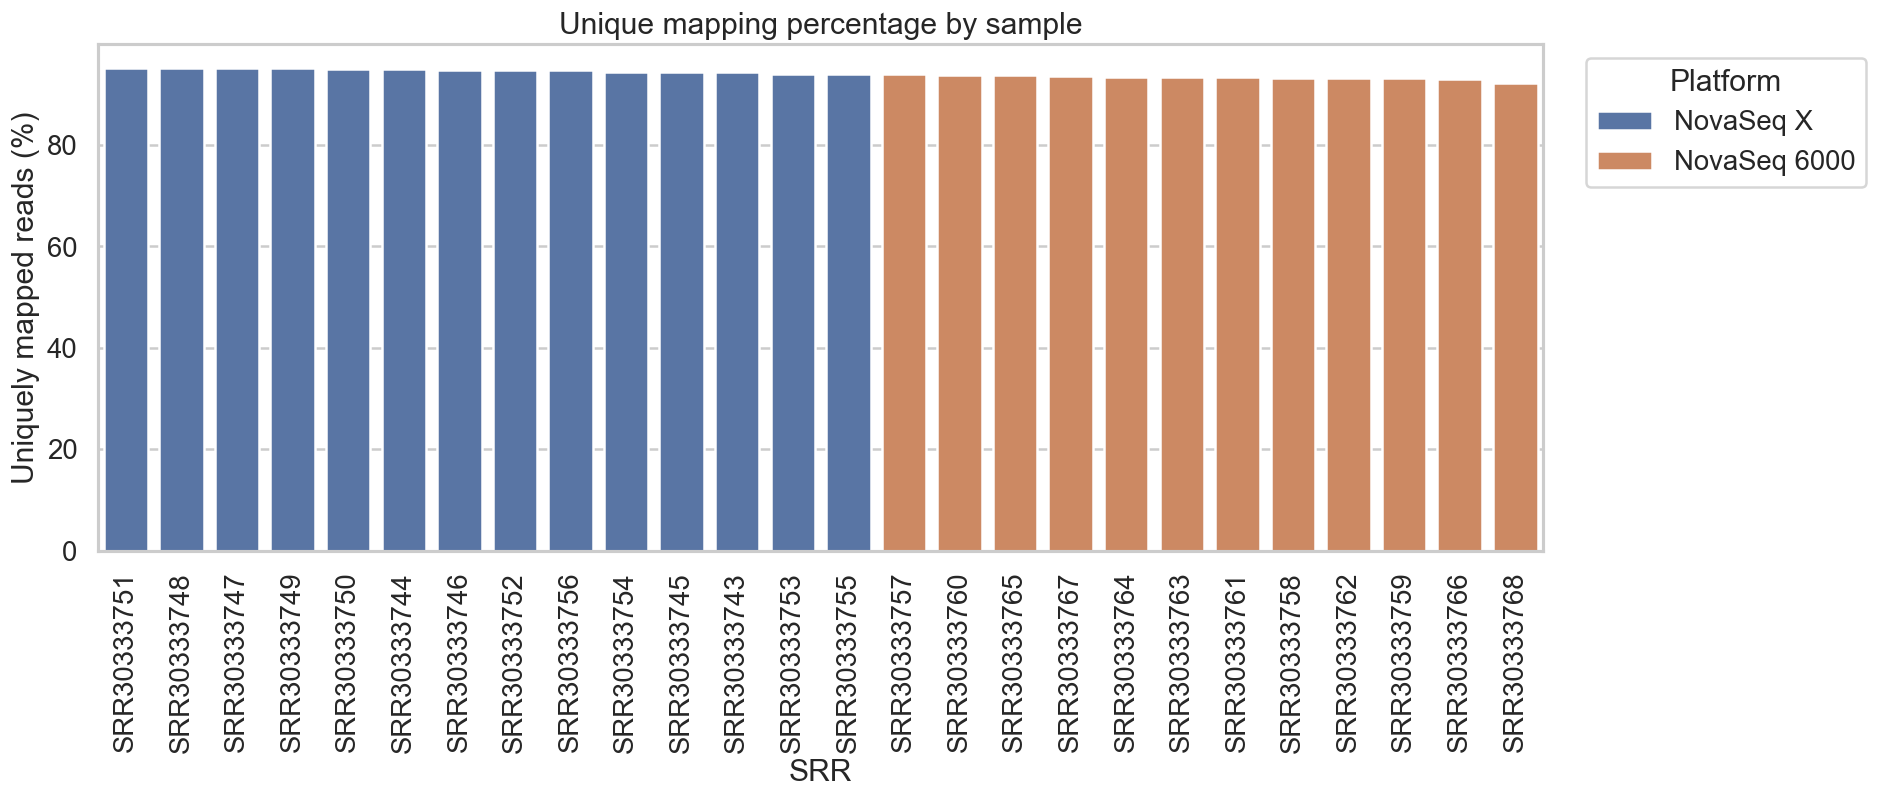

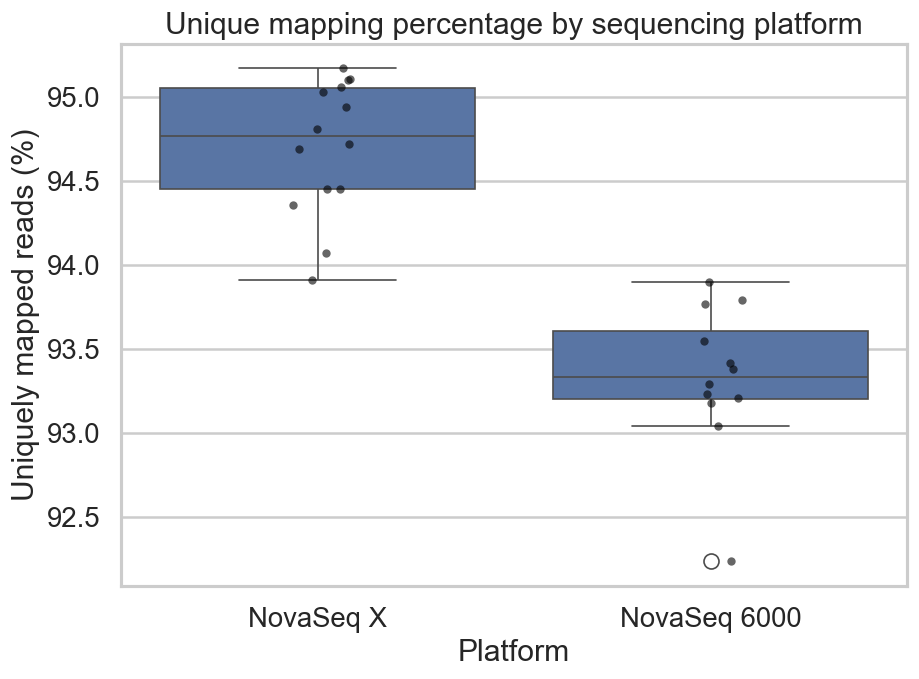

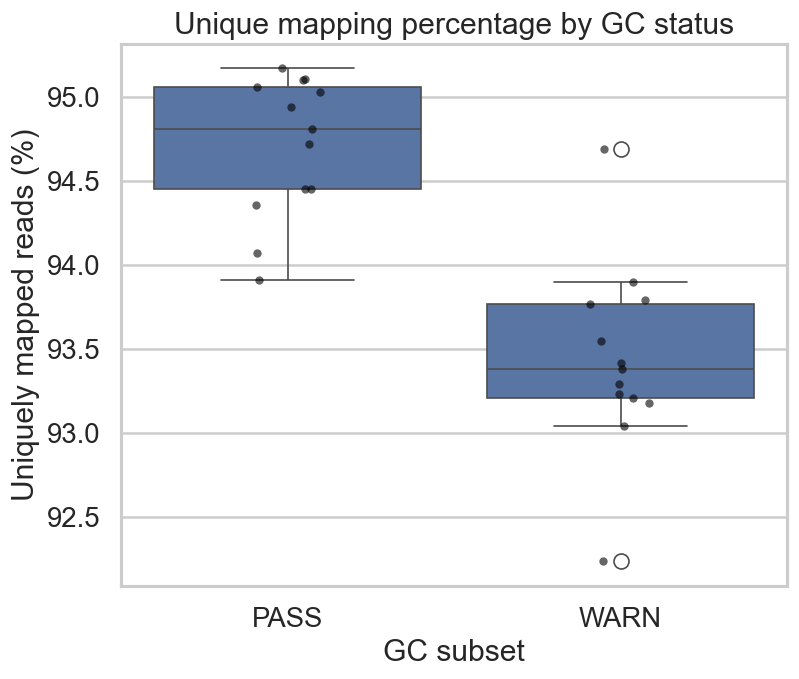

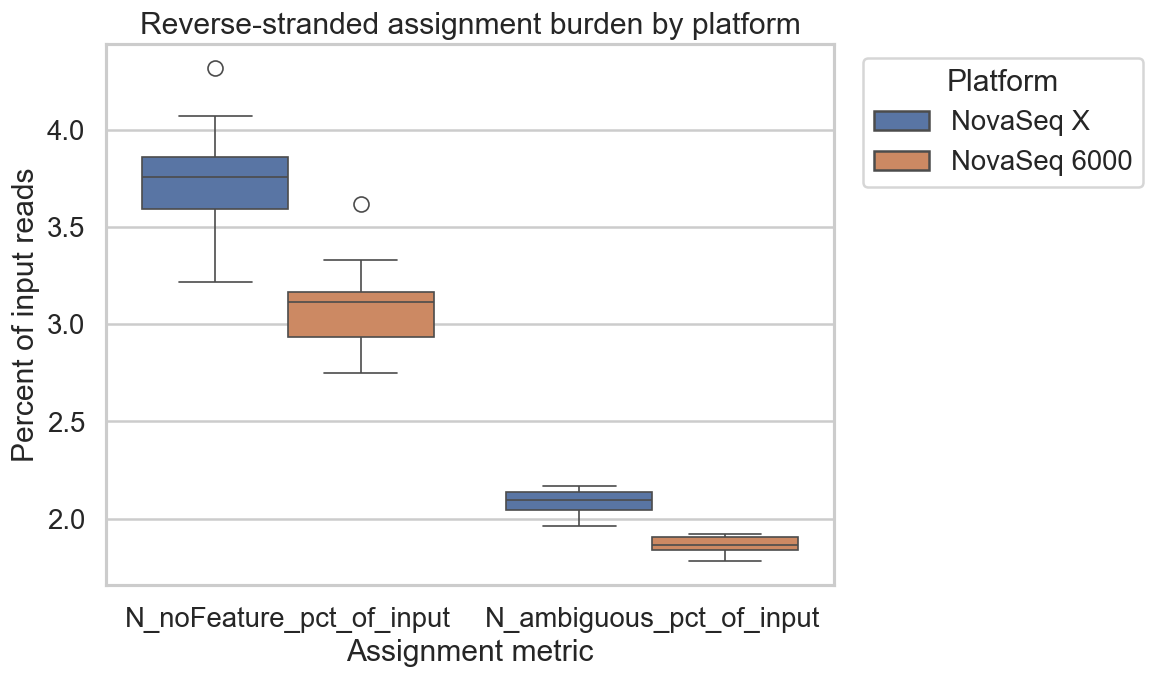

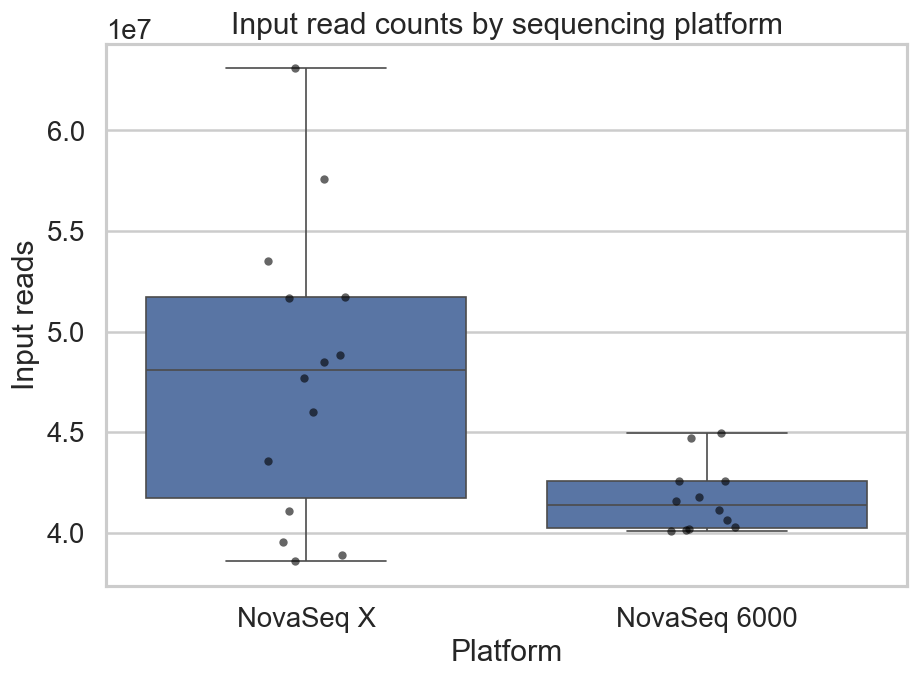

In [12]:

plot_df = sample_summary.copy().sort_values('unique_pct', ascending=False)
plot_df['sample_label'] = plot_df['srr'] + ' | ' + plot_df['sample_title'].fillna('')

# 1) Unique mapping by sample
fig, ax = plt.subplots(figsize=(16, 7))
sns.barplot(data=plot_df, x='srr', y='unique_pct', hue='platform_short', dodge=False, ax=ax)
ax.set_title('Unique mapping percentage by sample')
ax.set_xlabel('SRR')
ax.set_ylabel('Uniquely mapped reads (%)')
ax.tick_params(axis='x', rotation=90)
ax.legend(title='Platform', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / 'unique_mapping_by_sample.png', bbox_inches='tight')
plt.show()

# 2) Mapping rate by platform
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=sample_summary, x='platform_short', y='unique_pct', ax=ax)
sns.stripplot(data=sample_summary, x='platform_short', y='unique_pct', color='black', alpha=0.6, ax=ax)
ax.set_title('Unique mapping percentage by sequencing platform')
ax.set_xlabel('Platform')
ax.set_ylabel('Uniquely mapped reads (%)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'unique_mapping_by_platform.png', bbox_inches='tight')
plt.show()

# 3) Mapping rate by GC status
fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=sample_summary, x='gc_status', y='unique_pct', ax=ax, order=['PASS', 'WARN'])
sns.stripplot(data=sample_summary, x='gc_status', y='unique_pct', color='black', alpha=0.6, ax=ax, order=['PASS', 'WARN'])
ax.set_title('Unique mapping percentage by GC status')
ax.set_xlabel('GC subset')
ax.set_ylabel('Uniquely mapped reads (%)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'unique_mapping_by_gc_status.png', bbox_inches='tight')
plt.show()

# 4) Reverse-stranded noFeature / ambiguous burden by platform
assign_long = sample_summary.melt(
    id_vars=['srr', 'platform_short', 'gc_status'],
    value_vars=['N_noFeature_pct_of_input', 'N_ambiguous_pct_of_input'],
    var_name='assignment_metric',
    value_name='percent_of_input'
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=assign_long, x='assignment_metric', y='percent_of_input', hue='platform_short', ax=ax)
ax.set_title('Reverse-stranded assignment burden by platform')
ax.set_xlabel('Assignment metric')
ax.set_ylabel('Percent of input reads')
ax.legend(title='Platform', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / 'assignment_burden_by_platform.png', bbox_inches='tight')
plt.show()

# 5) Input read counts by platform
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=sample_summary, x='platform_short', y='input_reads', ax=ax)
sns.stripplot(data=sample_summary, x='platform_short', y='input_reads', color='black', alpha=0.6, ax=ax)
ax.set_title('Input read counts by sequencing platform')
ax.set_xlabel('Platform')
ax.set_ylabel('Input reads')
fig.tight_layout()
fig.savefig(FIG_DIR / 'input_reads_by_platform.png', bbox_inches='tight')
plt.show()



## Interpretation

This final cell turns the summary tables into a concise alignment-stage conclusion. The goal is not to do DE here; it is to decide whether the alignment layer supports moving forward with the full dataset and whether platform/GC structure needs to be carried into the next analysis step.


In [13]:

overall_median_unique = sample_summary['unique_pct'].median()
platform_medians = sample_summary.groupby('platform_short')['unique_pct'].median().sort_values(ascending=False)
gc_medians = sample_summary.groupby('gc_status')['unique_pct'].median().sort_values(ascending=False)
platform_delta = platform_medians.max() - platform_medians.min()
gc_delta = gc_medians.max() - gc_medians.min()

interp = f"""
### Alignment-stage interpretation

- All **26/26** samples produced STAR `Log.final.out` and `ReadsPerGene.out.tab` outputs, and the median unique-mapping rate is **{overall_median_unique:.2f}%**.
- The platform split is visible but not catastrophic: the median unique-mapping difference between the two sequencing platforms is **{platform_delta:.2f} percentage points**.
- The GC subset also remains visible at alignment, with a median unique-mapping difference of **{gc_delta:.2f} percentage points** between `GC_PASS` and `GC_WARN` samples.
- The GC-WARN samples do **not** collapse at alignment; instead, they trend toward **higher multi-mapping** and slightly lower unique-mapping, which is consistent with a structured cohort/platform effect rather than a simple failed-sample subset.
- The alignment metrics support **proceeding with the full dataset**, but downstream work should keep the platform split and the GC-WARN label available as explicit comparison variables when interpreting count-level behavior and any later DE results.
- The recommended count-matrix handoff for later DE work is: `mouse_star_gene_counts_reverse_stranded.tsv`.
"""

display(Markdown(interp))
print('Output directory:', OUT_DIR)
print('Figures:', FIG_DIR)
print('Tables:', TABLE_DIR)



### Alignment-stage interpretation

- All **26/26** samples produced STAR `Log.final.out` and `ReadsPerGene.out.tab` outputs, and the median unique-mapping rate is **93.99%**.
- The platform split is visible but not catastrophic: the median unique-mapping difference between the two sequencing platforms is **1.43 percentage points**.
- The GC subset also remains visible at alignment, with a median unique-mapping difference of **1.43 percentage points** between `GC_PASS` and `GC_WARN` samples.
- The GC-WARN samples do **not** collapse at alignment; instead, they trend toward **higher multi-mapping** and slightly lower unique-mapping, which is consistent with a structured cohort/platform effect rather than a simple failed-sample subset.
- The alignment metrics support **proceeding with the full dataset**, but downstream work should keep the platform split and the GC-WARN label available as explicit comparison variables when interpreting count-level behavior and any later DE results.
- The recommended count-matrix handoff for later DE work is: `mouse_star_gene_counts_reverse_stranded.tsv`.


Output directory: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/alignment_analysis_star_all26
Figures: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/alignment_analysis_star_all26/figures
Tables: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse/alignment_analysis_star_all26/tables
